In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 选择系统中已有的中文字体（从你的字体列表中选一个）
font_path = "/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc"  # 文泉驿微米黑
# 或思源黑体：font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

# 全局设置字体
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

# 验证配置是否生效
print("当前字体配置：", plt.rcParams["font.family"])

当前字体配置： ['WenQuanYi Zen Hei']


Frames: 991
Estimated Frequency: 30.30 Hz


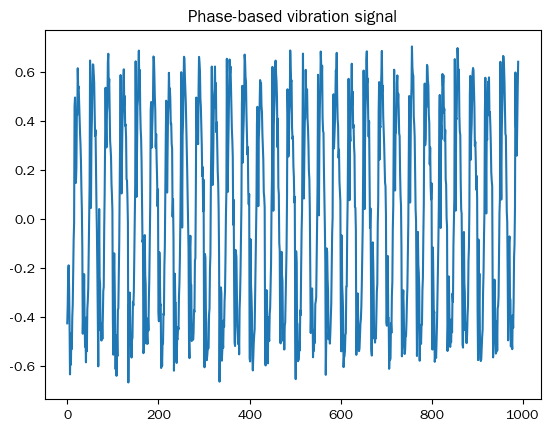

In [5]:
import h5py
import matplotlib.pyplot as plt
import cv2
import numpy as np

def load_events(file_path):
    with h5py.File(file_path, 'r') as f:
        e = f['CD/events'][:]
        return {
            'x': e['x'].astype(float),
            'y': e['y'].astype(float),
            't': e['t'].astype(float) * 1e-6
        }

def select_large_roi(data, x_min, x_max, y_min, y_max, t_min, t_max):
    mask = (data['x'] >= x_min) & (data['x'] <= x_max) & \
           (data['y'] >= y_min) & (data['y'] <= y_max) & \
           (data['t'] >= t_min) & (data['t'] <= t_max)
    return {k: v[mask] for k, v in data.items()}


def events_to_frames(events, frame_dt=0.002):

    xmin, xmax = int(events['x'].min()), int(events['x'].max())
    ymin, ymax = int(events['y'].min()), int(events['y'].max())

    W = xmax - xmin + 1
    H = ymax - ymin + 1

    t0, t1 = events['t'].min(), events['t'].max()

    frames = []
    times = []

    for k in range(int((t1 - t0) / frame_dt)):

        ta = t0 + k * frame_dt
        tb = ta + frame_dt

        mask = (events['t'] >= ta) & (events['t'] < tb)

        if np.sum(mask) < 50:
            continue

        frame = np.zeros((H, W), np.float32)

        xs = (events['x'][mask] - xmin).astype(int)
        ys = (events['y'][mask] - ymin).astype(int)

        for x, y in zip(xs, ys):
            frame[y, x] += 1

        frames.append(frame)
        times.append((ta + tb) / 2)

    return np.array(frames), np.array(times)


def complex_gabor(frame, ksize=31, sigma=4.0, theta=np.pi/2, lambd=10.0):

    # 实部
    real = cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd, gamma=0.5, psi=0)

    # 虚部（90°相移）
    imag = cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd, gamma=0.5, psi=np.pi/2)

    real_resp = cv2.filter2D(frame, cv2.CV_32F, real)
    imag_resp = cv2.filter2D(frame, cv2.CV_32F, imag)

    return real_resp + 1j * imag_resp
def method_phase_csp(frames, times):

    complex_stack = []

    for f in frames:

        # ⭐ 关键：选方向（垂直方向，因为是上下振动）
        resp = complex_gabor(f, theta=np.pi/2)

        complex_stack.append(resp)

    complex_stack = np.array(complex_stack)

    # 相位 & 幅值
    phase = np.angle(complex_stack)
    amp   = np.abs(complex_stack)

    # ===== 时间展开（关键）=====
    phase_unwrap = np.unwrap(phase, axis=0)

    # ===== 相位差 =====
    dphi = np.diff(phase_unwrap, axis=0)

    dt = times[1] - times[0]

    # ===== 加权平均（抗噪关键）=====
    signal = np.sum(dphi * amp[:-1], axis=(1,2)) / \
             (np.sum(amp[:-1], axis=(1,2)) + 1e-6)

    # ===== 频率估计 =====
    fft = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(len(signal), dt)

    f_est = freqs[np.argmax(np.abs(fft))]

    return f_est, signal

def main():

    # file_path = "./data/4.14_20hz.hdf5"
    # data = load_events(file_path)
    # roi = select_large_roi(
    #     data,
    #     600, 1000,
    #     100, 180,
    #     0, 0.2
    # )

    # file_path = './data/4.14_20hz.hdf5'  # 替换为你的HDF5文件路径
    # roi_x_min, roi_x_max = 600, 1000  # 定义ROI区域的x坐标范围
    # roi_y_min, roi_y_max = 100, 180  # 定义ROI区域的y坐标范围
    # t_min, t_max = 0,1000000  
    # group_size = 100                    # 每组100像素
    # step_size = 50


    # file_path = './data/20hz-2-20.hdf5'  # 替换为你的文件路径
    # roi_x_min, roi_x_max = 100, 300    # x范围
    # roi_y_min, roi_y_max = 420, 470 
    # t_min, t_max = 0,100000

    # file_path = './data/20hz-2-20.hdf5'  # 替换为你的HDF5文件路径
    # data = load_events(file_path)

    # roi = select_large_roi(
    #     data,
    #     100, 300,
    #     420, 470,
    #     0, 0.8
    # )

    # file_path = './data/zdbiaochi.hdf5'  # 替换为你的文件路径
    # roi_x_min, roi_x_max = 500, 1000    # x范围
    # roi_y_min, roi_y_max = 400, 600     # y范围
    # t_min, t_max = 0, 200000            # 时间范围（微秒）
    # group_size = 100                    # 每组100像素
    # step_size = 50 

    # file_path = './data/zdbiaochi.hdf5'  # 替换为你的HDF5文件路径
    # data = load_events(file_path)
    # roi = select_large_roi(
    #     data,
    #     500, 800,
    #     400, 600,
    #     0, 0.2
    # )
    
    
    # file_path = './data/30hz-20.hdf5'  # 替换为你的HDF5文件路径
    # roi_x_min, roi_x_max = 100, 600  # 定义ROI区域的x坐标范围
    # roi_y_min, roi_y_max = 420, 460  # 定义ROI区域的y坐标范围
    # t_min, t_max = 0,100000  # 定义时间范围

    file_path = "./data/30hz-20.hdf5"
    data = load_events(file_path)
    roi = select_large_roi(
        data,
        100, 600,
        420, 460,
        0, 1.0
    )    
    
    # file_path = './data/200hz-20.hdf5'  # 替换为你的HDF5文件路径
    # data = load_events(file_path)

    # roi = select_large_roi(
    #     data,
    #     200, 600,
    #     350, 460,
    #     0, 0.5
    # )
    
    frames, times = events_to_frames(roi, frame_dt=0.001)

    print(f"Frames: {len(frames)}")

    f_est, signal = method_phase_csp(frames, times)

    print(f"Estimated Frequency: {f_est:.2f} Hz")

    # 可视化信号
    plt.plot(signal)
    plt.title("Phase-based vibration signal")
    plt.show()


if __name__ == "__main__":
    main()

Events in ROI: 2568152
Frames: 495
Building complex responses...

Estimated Frequency: 30.36 Hz


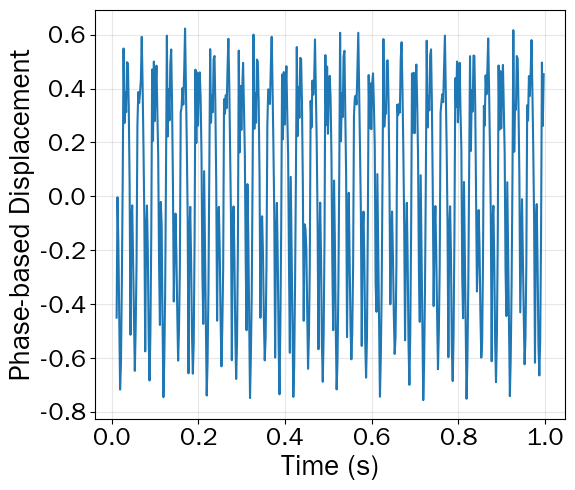

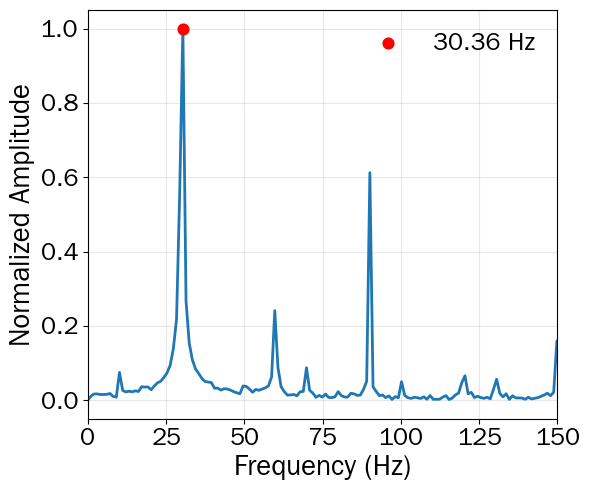

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import cv2


# =========================================================
# 1. 读取事件
# =========================================================
def load_events(file_path):
    with h5py.File(file_path, 'r') as f:
        e = f['CD/events'][:]
        return {
            'x': e['x'].astype(float),
            'y': e['y'].astype(float),
            't': e['t'].astype(float) * 1e-6
        }


def select_large_roi(data,
                     x_min, x_max,
                     y_min, y_max,
                     t_min, t_max):

    mask = (
        (data['x'] >= x_min) &
        (data['x'] <= x_max) &
        (data['y'] >= y_min) &
        (data['y'] <= y_max) &
        (data['t'] >= t_min) &
        (data['t'] <= t_max)
    )

    return {k: v[mask] for k, v in data.items()}


# =========================================================
# 2. 事件转帧
# =========================================================
def events_to_frames(events, frame_dt=0.001):

    xmin = int(events['x'].min())
    xmax = int(events['x'].max())

    ymin = int(events['y'].min())
    ymax = int(events['y'].max())

    W = xmax - xmin + 1
    H = ymax - ymin + 1

    t0 = events['t'].min()
    t1 = events['t'].max()

    frames = []
    times = []

    n_frames = int((t1 - t0) / frame_dt)

    for k in range(n_frames):

        ta = t0 + k * frame_dt
        tb = ta + frame_dt

        mask = (
            (events['t'] >= ta) &
            (events['t'] < tb)
        )

        if np.sum(mask) < 50:
            continue

        frame = np.zeros((H, W), np.float32)

        xs = (events['x'][mask] - xmin).astype(np.int32)
        ys = (events['y'][mask] - ymin).astype(np.int32)

        for x, y in zip(xs, ys):
            frame[y, x] += 1.0

        # 平滑一点
        frame = cv2.GaussianBlur(frame, (5,5), 0)

        frames.append(frame)
        times.append((ta + tb) / 2)

    return np.array(frames), np.array(times)


# =========================================================
# 3. 复 Gabor（CSP近似）
# =========================================================
def complex_gabor(frame,
                  ksize=31,
                  sigma=4.0,
                  theta=np.pi/2,
                  lambd=12.0):

    # 实部
    real_kernel = cv2.getGaborKernel(
        (ksize, ksize),
        sigma,
        theta,
        lambd,
        gamma=0.5,
        psi=0
    )

    # 虚部（90°相移）
    imag_kernel = cv2.getGaborKernel(
        (ksize, ksize),
        sigma,
        theta,
        lambd,
        gamma=0.5,
        psi=np.pi/2
    )

    real_resp = cv2.filter2D(frame, cv2.CV_32F, real_kernel)
    imag_resp = cv2.filter2D(frame, cv2.CV_32F, imag_kernel)

    return real_resp + 1j * imag_resp


# =========================================================
# 4. 相位振动分析
# =========================================================
def phase_vibration_analysis(frames, times):

    complex_stack = []

    print("Building complex responses...")

    for f in frames:

        # 上下振动 → 使用垂直方向滤波器
        resp = complex_gabor(
            f,
            theta=np.pi/2
        )

        complex_stack.append(resp)

    complex_stack = np.array(complex_stack)

    # ---------------------------------------------
    # 相位和幅值
    # ---------------------------------------------
    phase = np.angle(complex_stack)
    amplitude = np.abs(complex_stack)

    # ---------------------------------------------
    # 时间方向 phase unwrap
    # ---------------------------------------------
    phase_unwrap = np.unwrap(phase, axis=0)

    # ---------------------------------------------
    # phase difference
    # ---------------------------------------------
    dphi = np.diff(phase_unwrap, axis=0)

    # ---------------------------------------------
    # amplitude weighted averaging
    # ---------------------------------------------
    signal = np.sum(
        dphi * amplitude[:-1],
        axis=(1,2)
    ) / (
        np.sum(amplitude[:-1], axis=(1,2)) + 1e-6
    )

    signal = signal - np.mean(signal)

    # ---------------------------------------------
    # FFT
    # ---------------------------------------------
    dt = times[1] - times[0]

    fft_vals = np.fft.rfft(signal)

    freqs = np.fft.rfftfreq(
        len(signal),
        d=dt
    )

    spectrum = np.abs(fft_vals)

    f_est = freqs[np.argmax(spectrum)]

    print(f"\nEstimated Frequency: {f_est:.2f} Hz")

    return signal, freqs, spectrum, f_est


# =========================================================
# 5. 可视化
# =========================================================
def visualize_results(times,
                      signal,
                      freqs,
                      spectrum,
                      f_est):

    # -----------------------------------------------------
    # 可视化参数
    # -----------------------------------------------------
    grid_alpha = 0.3

    label_fontsize = 20
    tick_fontsize = 18
    title_fontsize = 22

    # =====================================================
    # 时间振动信号
    # =====================================================
    plt.figure(figsize=(6,5))

    plt.plot(
        times[1:],
        signal,
        lw=1.5
    )

    plt.xlabel(
        "Time (s)",
        fontsize=label_fontsize
    )

    plt.ylabel(
        "Phase-based Displacement",
        fontsize=label_fontsize
    )

    # plt.title(
    #     "Gabor Phase Signal",
    #     fontsize=title_fontsize
    # )

    plt.grid(alpha=grid_alpha)

    plt.tick_params(
        axis='both',
        labelsize=tick_fontsize
    )

    plt.tight_layout()

    plt.show()

    # =====================================================
    # 归一化频谱
    # =====================================================
    spectrum_norm = (
        spectrum /
        (spectrum.max() + 1e-12)
    )

    amp_peak = spectrum_norm[
        np.argmax(spectrum_norm)
    ]

    # =====================================================
    # 频谱图
    # =====================================================
    plt.figure(figsize=(6,5))

    plt.plot(
        freqs,
        spectrum_norm,
        lw=2
    )

    # 主频红点
    plt.scatter(
        f_est,
        amp_peak,
        color='r',
        s=60,
        zorder=3,
        label=f"{f_est:.2f} Hz"
    )

    plt.xlabel(
        "Frequency (Hz)",
        fontsize=label_fontsize
    )

    plt.ylabel(
        "Normalized Amplitude",
        fontsize=label_fontsize
    )

    plt.xlim(0,150)

    # plt.title(
    #     "Gabor Phase Spectrum",
    #     fontsize=title_fontsize
    # )

    plt.legend(
        frameon=False,
        fontsize=tick_fontsize,
        loc='upper right'
    )

    plt.grid(alpha=grid_alpha)

    plt.tick_params(
        axis='both',
        labelsize=tick_fontsize
    )

    plt.tight_layout()

    plt.show()


# =========================================================
# 6. 主函数
# =========================================================
def main():

    # file_path = "./data/zdbiaochi.hdf5"

    # data = load_events(file_path)

    # roi = select_large_roi(
    #     data,
    #     300, 1000,
    #     400, 600,
    #     0, 0.2
    # )



    # file_path = './data/4.14_20hz.hdf5'  # 替换为你的HDF5文件路径
    # roi_x_min, roi_x_max = 600, 1000  # 定义ROI区域的x坐标范围
    # roi_y_min, roi_y_max = 100, 180  # 定义ROI区域的y坐标范围
    # t_min, t_max = 0,1000000  
    # group_size = 100                    # 每组100像素
    # step_size = 50


    # file_path = './data/20hz-2-20.hdf5'  # 替换为你的文件路径
    # roi_x_min, roi_x_max = 100, 300    # x范围
    # roi_y_min, roi_y_max = 420, 470 
    # t_min, t_max = 0,100000

    # file_path = './data/20hz-2-20.hdf5'  # 替换为你的HDF5文件路径
    # data = load_events(file_path)

    # roi = select_large_roi(
    #     data,
    #     100, 300,
    #     420, 470,
    #     0, 0.8
    # )

    # file_path = './data/zdbiaochi.hdf5'  # 替换为你的文件路径
    # roi_x_min, roi_x_max = 500, 1000    # x范围
    # roi_y_min, roi_y_max = 400, 600     # y范围
    # t_min, t_max = 0, 200000            # 时间范围（微秒）
    # group_size = 100                    # 每组100像素
    # step_size = 50 

    # file_path = './data/zdbiaochi.hdf5'  # 替换为你的HDF5文件路径
    # data = load_events(file_path)
    # roi = select_large_roi(
    #     data,
    #     600, 700,
    #     400, 600,
    #     0, 1.0
    # )
    
    
    # file_path = './data/30hz-20.hdf5'  # 替换为你的HDF5文件路径
    # roi_x_min, roi_x_max = 100, 600  # 定义ROI区域的x坐标范围
    # roi_y_min, roi_y_max = 420, 460  # 定义ROI区域的y坐标范围
    # t_min, t_max = 0,100000  # 定义时间范围

    file_path = "./data/30hz-20.hdf5"
    data = load_events(file_path)
    roi = select_large_roi(
        data,
        100, 600,
        420, 460,
        0, 1.0
    )    
    
    # file_path = './data/200hz-20.hdf5'  # 替换为你的HDF5文件路径
    # data = load_events(file_path)

    # roi = select_large_roi(
    #     data,
    #     200, 600,
    #     350, 460,
    #     0, 0.5
    # )


    # h5_path = "./data/100hz-20.hdf5"   # 替换为你的文件
    # # ROI 为整幅图中杆的区域 (x1,y1,x2,y2) 
    # roi = (200, 420, 600, 460)
    
    # file_path = './data/100hz-20.hdf5'  # 替换为你的HDF5文件路径
    # data = load_events(file_path)

    # roi = select_large_roi(
    #     data,
    #     200, 600,
    #     420, 460,
    #     0, 0.5
    # )
    print(f"Events in ROI: {len(roi['x'])}")

    # -----------------------------------------------------
    # 事件转帧
    # -----------------------------------------------------
    frames, times = events_to_frames(
        roi,
        frame_dt=0.002
    )

    print(f"Frames: {len(frames)}")

    # -----------------------------------------------------
    # 相位分析
    # -----------------------------------------------------
    signal, freqs, spectrum, f_est = \
        phase_vibration_analysis(
            frames,
            times
        )

    # -----------------------------------------------------
    # 可视化
    # -----------------------------------------------------
    visualize_results(
        times,
        signal,
        freqs,
        spectrum,
        f_est
    )


# =========================================================
# main
# =========================================================
if __name__ == "__main__":
    main()

Events in ROI: 2743944
Frames: 992
Building complex Gabor responses...

Estimated Frequency: 25.23 Hz

========== Phase-based Result ==========
Dominant Frequency : 25.227 Hz
Estimated Displacement Amplitude : 12.815 px


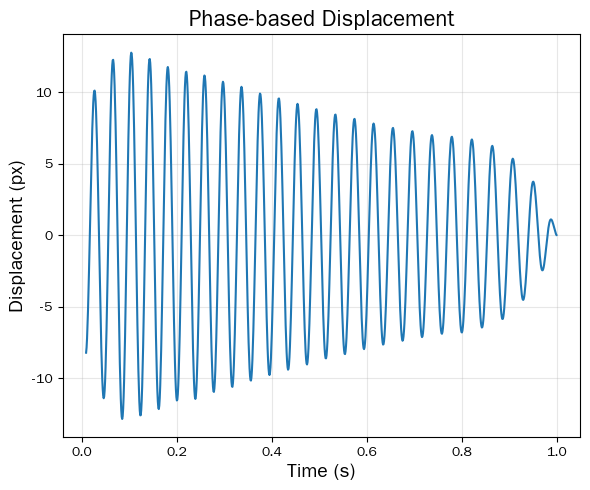

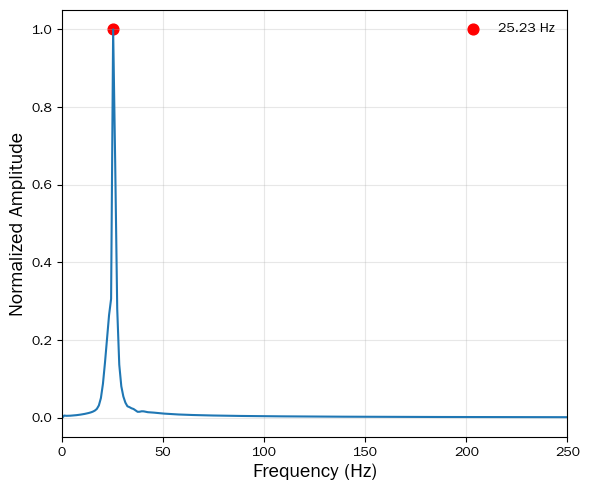

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import cv2

from scipy.ndimage import gaussian_filter1d
from scipy.signal import butter, filtfilt, detrend

# =========================================================
# 1. 读取事件
# =========================================================
def load_events(file_path):

    with h5py.File(file_path, 'r') as f:

        e = f['CD/events'][:]

        return {
            'x': e['x'].astype(np.float32),
            'y': e['y'].astype(np.float32),
            't': e['t'].astype(np.float64) * 1e-6
        }


# =========================================================
# 2. ROI
# =========================================================
def select_large_roi(data,
                     x_min, x_max,
                     y_min, y_max,
                     t_min, t_max):

    mask = (
        (data['x'] >= x_min) &
        (data['x'] <= x_max) &
        (data['y'] >= y_min) &
        (data['y'] <= y_max) &
        (data['t'] >= t_min) &
        (data['t'] <= t_max)
    )

    return {
        k: v[mask]
        for k, v in data.items()
    }


# =========================================================
# 3. 事件转帧
# =========================================================
def events_to_frames(events,
                     frame_dt=0.001):

    xmin = int(events['x'].min())
    xmax = int(events['x'].max())

    ymin = int(events['y'].min())
    ymax = int(events['y'].max())

    W = xmax - xmin + 1
    H = ymax - ymin + 1

    t0 = events['t'].min()
    t1 = events['t'].max()

    frames = []
    times = []

    n_frames = int((t1 - t0) / frame_dt)

    for k in range(n_frames):

        ta = t0 + k * frame_dt
        tb = ta + frame_dt

        mask = (
            (events['t'] >= ta) &
            (events['t'] < tb)
        )

        if np.sum(mask) < 50:
            continue

        frame = np.zeros((H, W), np.float32)

        xs = (
            events['x'][mask] - xmin
        ).astype(np.int32)

        ys = (
            events['y'][mask] - ymin
        ).astype(np.int32)

        for x, y in zip(xs, ys):
            frame[y, x] += 1.0

        # 平滑
        frame = cv2.GaussianBlur(
            frame,
            (5, 5),
            0
        )

        frames.append(frame)

        times.append((ta + tb) / 2)

    return np.array(frames), np.array(times)


# =========================================================
# 4. Complex Gabor
# =========================================================
def complex_gabor(frame,
                  ksize=31,
                  sigma=4.0,
                  theta=np.pi/2,
                  lambd=12.0):

    # 实部
    real_kernel = cv2.getGaborKernel(
        (ksize, ksize),
        sigma,
        theta,
        lambd,
        gamma=0.5,
        psi=0
    )

    # 虚部
    imag_kernel = cv2.getGaborKernel(
        (ksize, ksize),
        sigma,
        theta,
        lambd,
        gamma=0.5,
        psi=np.pi/2
    )

    real_resp = cv2.filter2D(
        frame,
        cv2.CV_32F,
        real_kernel
    )

    imag_resp = cv2.filter2D(
        frame,
        cv2.CV_32F,
        imag_kernel
    )

    return real_resp + 1j * imag_resp


# =========================================================
# 5. Butterworth 带通滤波
# =========================================================
def bandpass_filter(signal,
                    fs,
                    lowcut,
                    highcut,
                    order=4):

    nyq = 0.5 * fs

    low = lowcut / nyq
    high = highcut / nyq

    b, a = butter(
        order,
        [low, high],
        btype='band'
    )

    return filtfilt(b, a, signal)


# =========================================================
# 6. Phase-based displacement
# =========================================================
def phase_displacement_analysis(frames,
                                times,
                                lambd=12.0,
                                smooth_sigma=1.0,
                                lowcut=20,
                                highcut=40):

    print("Building complex Gabor responses...")

    complex_stack = []

    # -----------------------------------------------------
    # complex Gabor
    # -----------------------------------------------------
    for f in frames:

        resp = complex_gabor(
            f,
            theta=np.pi/2,
            lambd=lambd
        )

        complex_stack.append(resp)

    complex_stack = np.array(complex_stack)

    # -----------------------------------------------------
    # phase + amplitude
    # -----------------------------------------------------
    phase = np.angle(complex_stack)

    amplitude = np.abs(complex_stack)

    # -----------------------------------------------------
    # unwrap
    # -----------------------------------------------------
    phase_unwrap = np.unwrap(
        phase,
        axis=0
    )

    # -----------------------------------------------------
    # phase difference
    # -----------------------------------------------------
    dphi = np.diff(
        phase_unwrap,
        axis=0
    )

    # -----------------------------------------------------
    # weighted averaging
    # -----------------------------------------------------
    dphi_signal = np.sum(
        dphi * amplitude[:-1],
        axis=(1, 2)
    ) / (
        np.sum(amplitude[:-1], axis=(1, 2)) + 1e-6
    )

    dphi_signal -= np.mean(dphi_signal)

    # -----------------------------------------------------
    # phase increment -> displacement increment
    # -----------------------------------------------------
    dx = (
        dphi_signal *
        lambd /
        (2 * np.pi)
    )

    # =====================================================
    # 关键：
    # bandpass 去除 drift
    # =====================================================
    fs = 1.0 / np.mean(np.diff(times))

    dx_filtered = bandpass_filter(
        dx,
        fs,
        lowcut,
        highcut
    )

    # =====================================================
    # displacement reconstruction
    # =====================================================
    displacement = np.cumsum(dx_filtered)

    # 去趋势
    displacement = detrend(displacement)

    # 平滑
    displacement = gaussian_filter1d(
        displacement,
        sigma=smooth_sigma
    )

    # =====================================================
    # FFT
    # =====================================================
    fft_vals = np.fft.rfft(displacement)

    freqs = np.fft.rfftfreq(
        len(displacement),
        d=1/fs
    )

    spectrum = np.abs(fft_vals)

    spectrum /= spectrum.max() + 1e-12

    idx = np.argmax(spectrum)

    f_est = freqs[idx]

    print(f"\nEstimated Frequency: {f_est:.2f} Hz")

    return (
        displacement,
        freqs,
        spectrum,
        f_est
    )


# =========================================================
# 7. 可视化
# =========================================================
def visualize_results(times,
                      displacement,
                      freqs,
                      spectrum,
                      f_est):

    # -----------------------------------------------------
    # displacement
    # -----------------------------------------------------
    plt.figure(figsize=(6,5))

    plt.plot(
        times[1:],
        displacement,
        linewidth=1.5
    )

    plt.xlabel("Time (s)", fontsize=14)

    plt.ylabel("Displacement (px)", fontsize=14)

    plt.title(
        "Phase-based Displacement",
        fontsize=16
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

    # -----------------------------------------------------
    # spectrum
    # -----------------------------------------------------
    plt.figure(figsize=(6,5))

    plt.plot(
        freqs,
        spectrum,
        linewidth=1.5
    )

    plt.scatter(
        f_est,
        spectrum[np.argmax(spectrum)],
        color='r',
        s=60,
        label=f"{f_est:.2f} Hz"
    )

    plt.xlabel("Frequency (Hz)", fontsize=14)

    plt.ylabel(
        "Normalized Amplitude",
        fontsize=14
    )

    plt.xlim(0, 250)

    plt.legend(frameon=False)

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()


# =========================================================
# 8. 主函数
# =========================================================
def main():

    # =====================================================
    # 数据
    # =====================================================
    # file_path = "./data/30hz-20.hdf5"

    # data = load_events(file_path)

    # # =====================================================
    # # ROI
    # # =====================================================
    # roi = select_large_roi(
    #     data,
    #     100, 600,
    #     420, 460,
    #     0, 1.0
    # )


    file_path = "./data/zdbiaochi.hdf5"

    data = load_events(file_path)

    # =====================================================
    # ROI
    # =====================================================
    roi = select_large_roi(
        data,
        600, 700,
        400, 600,
        0, 1.0
    )
    
    # FILE = "./data/zdbiaochi.hdf5"
    # ROI = (980, 1000, 400, 600)
    
    print(f"Events in ROI: {len(roi['x'])}")

    # =====================================================
    # 事件转帧
    # =====================================================
    frames, times = events_to_frames(
        roi,
        frame_dt=0.001
    )

    print(f"Frames: {len(frames)}")

    # =====================================================
    # 相位位移恢复
    # =====================================================
    displacement, freqs, spectrum, f_est = \
        phase_displacement_analysis(
            frames,
            times,
            lambd=12.0,
            smooth_sigma=1.0,

            # 已知频率附近带通
            lowcut=20,
            highcut=40
        )

    # =====================================================
    # amplitude
    # =====================================================
    amplitude = 0.5 * (
        displacement.max() -
        displacement.min()
    )

    print("\n========== Phase-based Result ==========")

    print(
        f"Dominant Frequency : "
        f"{f_est:.3f} Hz"
    )

    print(
        f"Estimated Displacement Amplitude : "
        f"{amplitude:.3f} px"
    )

    # =====================================================
    # visualize
    # =====================================================
    visualize_results(
        times,
        displacement,
        freqs,
        spectrum,
        f_est
    )


# =========================================================
# main
# =========================================================
if __name__ == "__main__":
    main()